<center>
<h1>Análitica de Datos para Negocios Digitales</h1>
</center>

<center>
<h3>Práctica 02: Introduccion al Uso de Python en el Análisis de Datos</h3>
</center>

Elaborado por: **María De Los Angeles García Cortez**  

Grado/Grupo: **9º "A" Ing. Entornos Virtuales y Negocios Digitales**

Matrícula: **230538** 

**1. Importamos la librerias de python para manipular y analizar datos**

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as mat
import seaborn as sea

**2. Creamos un DataFrame del origen d elos datos en este caso un archivo delimitado por comas**

Este comando perimte cargar en memoria cache(temporal), los datos que se van a analizar estan utilizando las librerias de panda que nos permite la manipulacion de datos.

In [8]:
df=pd.read_csv('UberDataset.csv')


**3. Omprimimos en pantalla los datos para verificar la carga completas**

**IMPORTANTE** 

La impresión de los datos del DATAFRAME no da contexto importante como el numnro de filas, el numero de columnas y en el caso de los datos **cuantitativos** una suma de total de las columnas, en caso de los casos **cualitativos** nos colocara en texto NaN (Not As Number) por defecto no s epuede sumar.

In [9]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**4. Leer los datos de una columna especifica**

El uso de **[Columna]** nos permite poder acceder a los datos de la columna del DataFrame, mostrando los 5 primeros y 5 ultimos el total de registro y el tipo de datos cabe mencionar que este comando.

In [11]:
df['PURPOSE']

0        Meal/Entertain
1                   NaN
2       Errand/Supplies
3               Meeting
4        Customer Visit
             ...       
1151     Temporary Site
1152            Meeting
1153     Temporary Site
1154     Temporary Site
1155                NaN
Name: PURPOSE, Length: 1156, dtype: object

**5. Manipulamos los datos cargados para obtener el total de cada valor registrado en la columna**

El metodo value.counts() es una función preprogramada de python que nos permite agrupar los registro por sus valores y obtener el total de cada valor detectado.

In [13]:
df['PURPOSE'].value_counts()

PURPOSE
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64

**6. Aplicamos las mismas funcion con otra columna**

En este caso vemos que tipo de viajes hizo el conductor, resultado **Business** (Negocios) o **'Personal'** (Autos personales).

In [14]:
df['CATEGORY'].value_counts()

CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

**Limpiamos el registros de los viajes que no tinen un localización de inicio**

In [15]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**7. Limpiamos los registros de los viajes que no son localizables**

Para este análisis, es importante limpiar los datos de la muestra que nos sirve para para nuestro analisis, empezamos por eliminar los registros (filas), de aquellos viajes que no registraron un destino localizable, para ello y utilizamos el comando logico de no igualdad (!=) para filtrar el dataframe, esto nos arroja a un resultado de boloeano "true" para los que tiene un destino localizable "false" para los que no.

In [16]:
df['STOP']!='Unknown Location'

0        True
1        True
2        True
3        True
4        True
        ...  
1150     True
1151    False
1153     True
1154     True
1155     True
Name: STOP, Length: 1008, dtype: bool

**8. Eliminamos del DataFrame los registros  que contengan false**

In [17]:
df[df['STOP']!='Unknown Location']

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**9. Sobreescribimos el DataFrame (df)** 

Para eliminar de nuestro análisis es decir que que el docimento de origen de los datos(csv) sigue sin cambios, asignamos el resultado.

In [18]:
df=df[df['STOP']!='Unknown Location']

**10. Volvemos a imprimir el dataframe** 

En este resultado en este resultado podemos observar que el numero dataframe cuanta con solo 1007 filas a diferencias del original que tenia 1156 es  decir se eliminaron 149 registros que no tenian un destino localizable.

In [19]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**11. Repetimos el proceso de limpieza ahora para los viajes que no tienen un origen localizable (SMART)**

En este caso hacemos toda la limpieza en una sola operacion, para el analisis de datos reduciendo de **1007** a **945** registros, incluyendo que hay **62** viajes que tuvieron un destino (STOP) pero no de origen (START).

In [20]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [21]:
def value(val):
    val=str(val)
    return val.replace('?','a')
df['START']=df['START'].apply(value)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**12. Conceptos de Repaso**

12.1 Funciones o metodos en Python:
Una funcion ometodo esun bloque de codigo reutilizable que realiza una tarea especifica.Sirve para evitar repetir instruccionbes y organizar mejor los programas.

    En el lenguaje de Programacion de Python las fucniones son declaradas con la palabra reservada **def**
    , y para ejecutarlas basta con escribir  el nombre que se le asigno 
    a la misma, el uso() es para enviar los datos de entrada en caso de que sean necesarios

In [22]:
def saludar():
    print("Hola Bienvenid@ a Python para el Analisis de Datos")

*Llamado:*

In [23]:
saludar()

Hola Bienvenid@ a Python para el Analisis de Datos


12.2 Funciones que reciben un parametro o datos de entrada

En algunas ocaciones es necesario enviar datos  para la ejecucion del metodo, para ello debemos declararlo en la definicion  de la funcion entre ()

*Definición*

In [24]:
def saludar_nombre(nombre):
    return f"Hola,{nombre} Bienvenid@ a Python para el Analisis de Datos"

*Llamado*

In [25]:
saludar_nombre("Angeles")

'Hola,Angeles Bienvenid@ a Python para el Analisis de Datos'

In [26]:
saludar_nombre("Mary")

'Hola,Mary Bienvenid@ a Python para el Analisis de Datos'

12.3 Funciones que mandan a llamar a otrras funciones y que regresan  el resultado de un procedimineto, en este caso utilizaremos
una funcion predefinida en Python denomindo *replace* que nos permite sustituir letras en una cadena de texto.

In [27]:
def sustituir_vocales(texto):
    texto = texto.replace("A",  "4")
    texto = texto.replace("a",  "4")

    texto = texto.replace("E",  "3")
    texto = texto.replace("e",  "3")

    texto = texto.replace("I",  "1")
    texto = texto.replace("i",  "1")

    texto = texto.replace("O",  "0")
    texto = texto.replace("o",  "0")

    texto = texto.replace("U",  "∪")
    texto = texto.replace("u",  "∪")

    return texto

*Llamado*

In [28]:
print(sustituir_vocales(saludar_nombre("Angeles")))

H0l4,4ng3l3s B13nv3n1d@ 4 Pyth0n p4r4 3l 4n4l1s1s d3 D4t0s


**13.Limpieza de letras ilegibles**

Ejecutamos el proceso de susticuion de las letras ilegibles(para este caso de estudio solo hay dos letras a con tilde que se cargaron con un ? y se limpian con una "a" para una mejor comprension del analisis

In [29]:
df['START'] = df['START'].astype(str).str.replace('?', 'a')
df['STOP'] = df['STOP'].astype(str).str.replace('?', 'a')
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**14.Rellenar datos vacios con un valor generico asignado**

Durante el proceso de limpieza y trasformación de los datos, existe la posiblilidad de coregir los datos que no se encuentran registrados, para este caso usaremos función de **Pandas** llamada  *filina* (Sirve para rellenar los datos no disponibles(not avaliable)

In [31]:
df['PURPOSE'].fillna('Other',inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Other
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**15.Medidas de tendencia central**

Una vez terminada la fase de limpieza de datos comenzamosd con la tendencia basica enb este caso consultaremos las medidas de tendencia central siendo:total, media, mediana, moda, cuatilla y desviación estándar, máximo y minimo.

Utilizaremos un método **describe** de nuestro dataframe se buscaron todos los cuantitativos (numeros) de la muestra y realizara el cálculo de estos 
valores , para este tenemos la columna **MILES**, la cual hace  referencia al total de millas terrestres(1.69 km) recorridos por el conducto en un servicio de viaje a traves de UBER.

In [32]:
df.describe()

,MILES
count,945.000000
mean,22.809841
std,397.276813
min,0.500000
25%,2.600000
50%,5.300000
75%,9.900000
max,12204.700000


Para el caso de mediana y moda, estas deben ser calculadas por separado a traves de las funciones .mode y .median

In [33]:
print(df['MILES'].mode())

0    9.9
Name: MILES, dtype: float64


In [34]:
print(df['MILES'].median())

5.3


**16.En conclusión** 

Este dataframe nos permite analizar una pequeña muestra de **945** viajes realizados a traves de la aplicaion de UBER, 
determinando que la distancia minima registrada es de  .5 millas y la maxima es de **12.204.700000** con un romedio de
**22.8**, siendo  la  distancia repetida de **9.9** millas y la mediana de **5.3** millas.

In [35]:
def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['START_DATE']=df['START_DATE'].apply(val)
df

def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['END_DATE']=df['END_DATE'].apply(val)
df

df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01/06/2016,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016,12/31/2016,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**17. Eliminamos la ultima fila de totales**

La ultima fila de totales no es necesaria para la graficacion dado que podria generar error en la presentacion de datos por ello la eliminacion de Dataframe 
usando el comando *drop* y el numero de las posicion de la fila a eliminar  encerrada entre cortchetes []

In [36]:
df.drop([1155], inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01/06/2016,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016,Business,Katunayake,Gampaha,6.4,Temporary Site


**18.Eliminamos los datos de los cuartiles menores**  

El código filtra el DataFrame para conservar únicamente los registros de la columna MILES cuyos valores se encuentran estrictamente entre el percentil **0.05** y el percentil **0.95**.

Con la finalidad de hacer un  analisis de los datos de tendencia es decir con mayor frecuencia eliminamos los registros que entrenan en el cuartil menor a 0.05 y mahyor a 0.95, utilizando la creación de un  nuevo dataframe(df3),recordando que la muestra completa sigue en el df original(df).

In [37]:
a=df['MILES'].quantile(0.95)
b=df['MILES'].quantile(0.05)
df3=df[df['MILES']>b]
df3=df[df['MILES']<a]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting


**19. Cálculo de la Desviación Estándar**

Para entender que tan variables o dispersas son las distancias de los viajes 

In [38]:
df3['STD']=df.MILES.std()
df3

C:\Users\Angel\AppData\Local\Temp\ipykernel_21056\672307851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['STD']=df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other,21.472805
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805
...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805


**20.Estimar el valor de Z-Score o puntuacion Z**
    
Con la finalidad de estimar la dispersión de los datos, es decir que tan variados o diferentes son, utilizamos esta formula para poder continuar con el analisis EDA(Exploratory Dat Analisys)


In [39]:
df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()
df3

C:\Users\Angel\AppData\Local\Temp\ipykernel_21056\2738585948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other,21.472805,-0.228442
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


**21. Filtramos aquello que no esten en el rango -1 y 1**

In [40]:
df['MILES'].describe()

count    944.000000
mean       9.905297
std       21.472805
min        0.500000
25%        2.600000
50%        5.300000
75%        9.900000
max      310.300000
Name: MILES, dtype: float64

In [41]:
df3['MILES'].describe()

count    896.000000
mean       6.344196
std        4.849186
min        0.500000
25%        2.500000
50%        4.900000
75%        9.025000
max       25.600000
Name: MILES, dtype: float64

In [42]:
df3=df3[(df3.Z>-1) & (df3.Z<1)]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other,21.472805,-0.228442
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


**22.Graficación Basica para un Analisis mas Visual Y Simplificado**

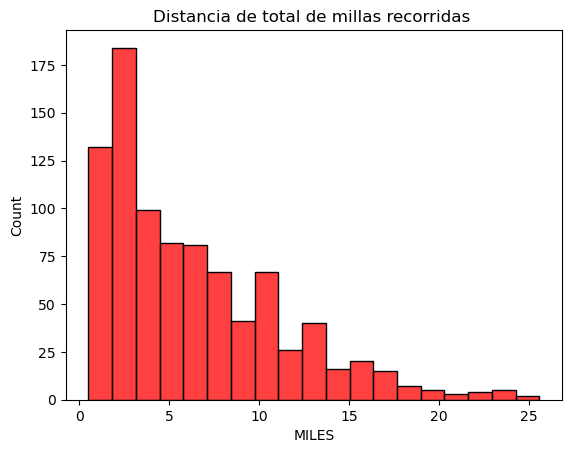

In [43]:
mat.title('Distancia de total de millas recorridas ')
sea.histplot(df3.MILES,color='RED')
mat.show()

**23.Gráfico de Clasificacion de Viajes por CATEGORIAS**

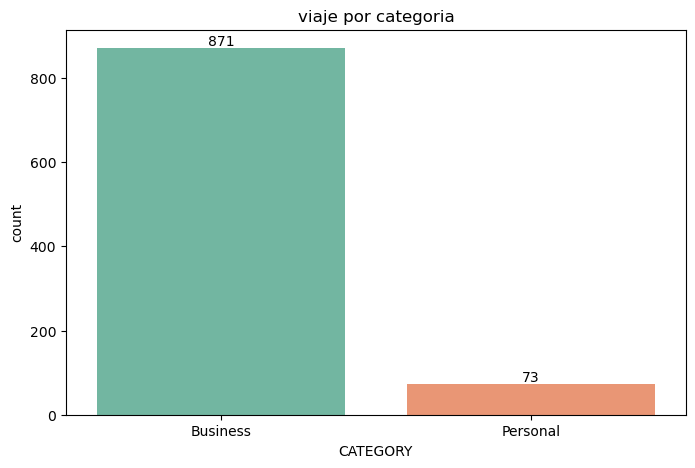

In [44]:
fig, ax = mat.subplots(figsize=(8,5))

grafica = sea.countplot(
    data=df,
    x='CATEGORY',
    hue='CATEGORY',
    palette='Set2',
    legend=False,
    ax=ax
)

ax.set_title('viaje por categoria')

for container in ax.containers:
    ax.bar_label(container)

mat.show()

**24. Gráfica de viajes por proposito (PURPOSE)**

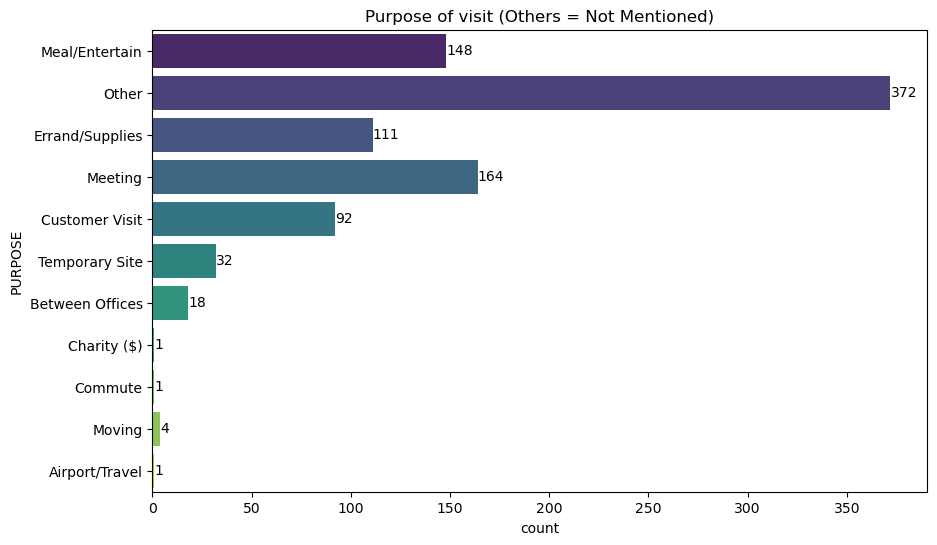

In [45]:
fig, ax = mat.subplots(figsize=(10,6))

grafica = sea.countplot(
    data=df,
    y='PURPOSE',
    hue='PURPOSE',
    dodge=False,
    palette='viridis',
    legend=False,

)

ax.set_title('Purpose of visit (Others = Not Mentioned)')

for container in ax.containers:
    ax.bar_label(container)

mat.show()

**25.Gráfico de Lugar de Abordaje (START)**

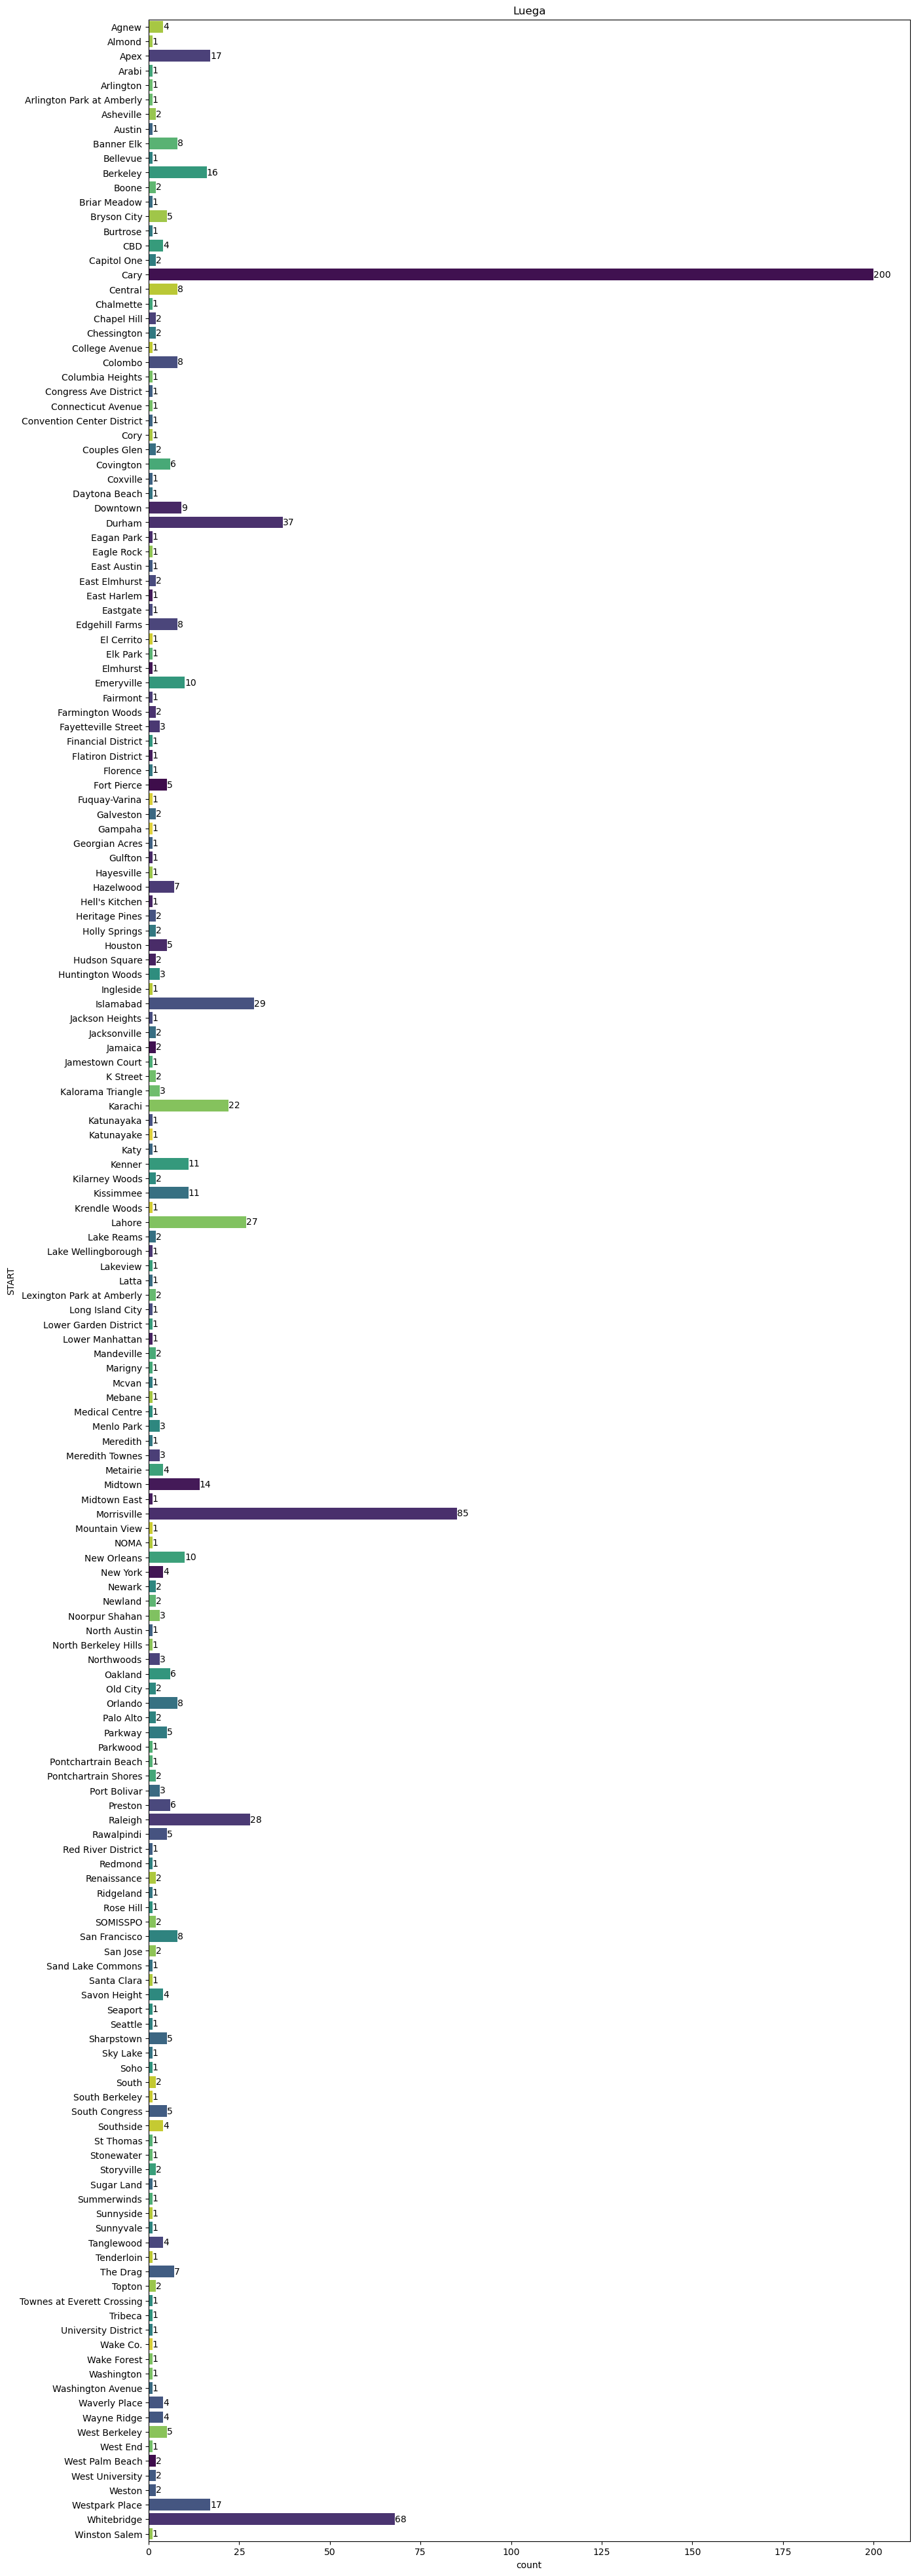

In [46]:
fig, ax = mat.subplots(figsize=(15,50))
# Ordenar alfabéticamente
orden = sorted(df['START'].dropna().unique())
grafica = sea.countplot(
    data=df,
    y='START',
    order=orden,
    hue='START',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)
# Título
ax.set_title('Luega')
# Agregar totales
for container in ax.containers:
    ax.bar_label(container)
mat.show()

**26.Grafico de Llegada (STOP)**

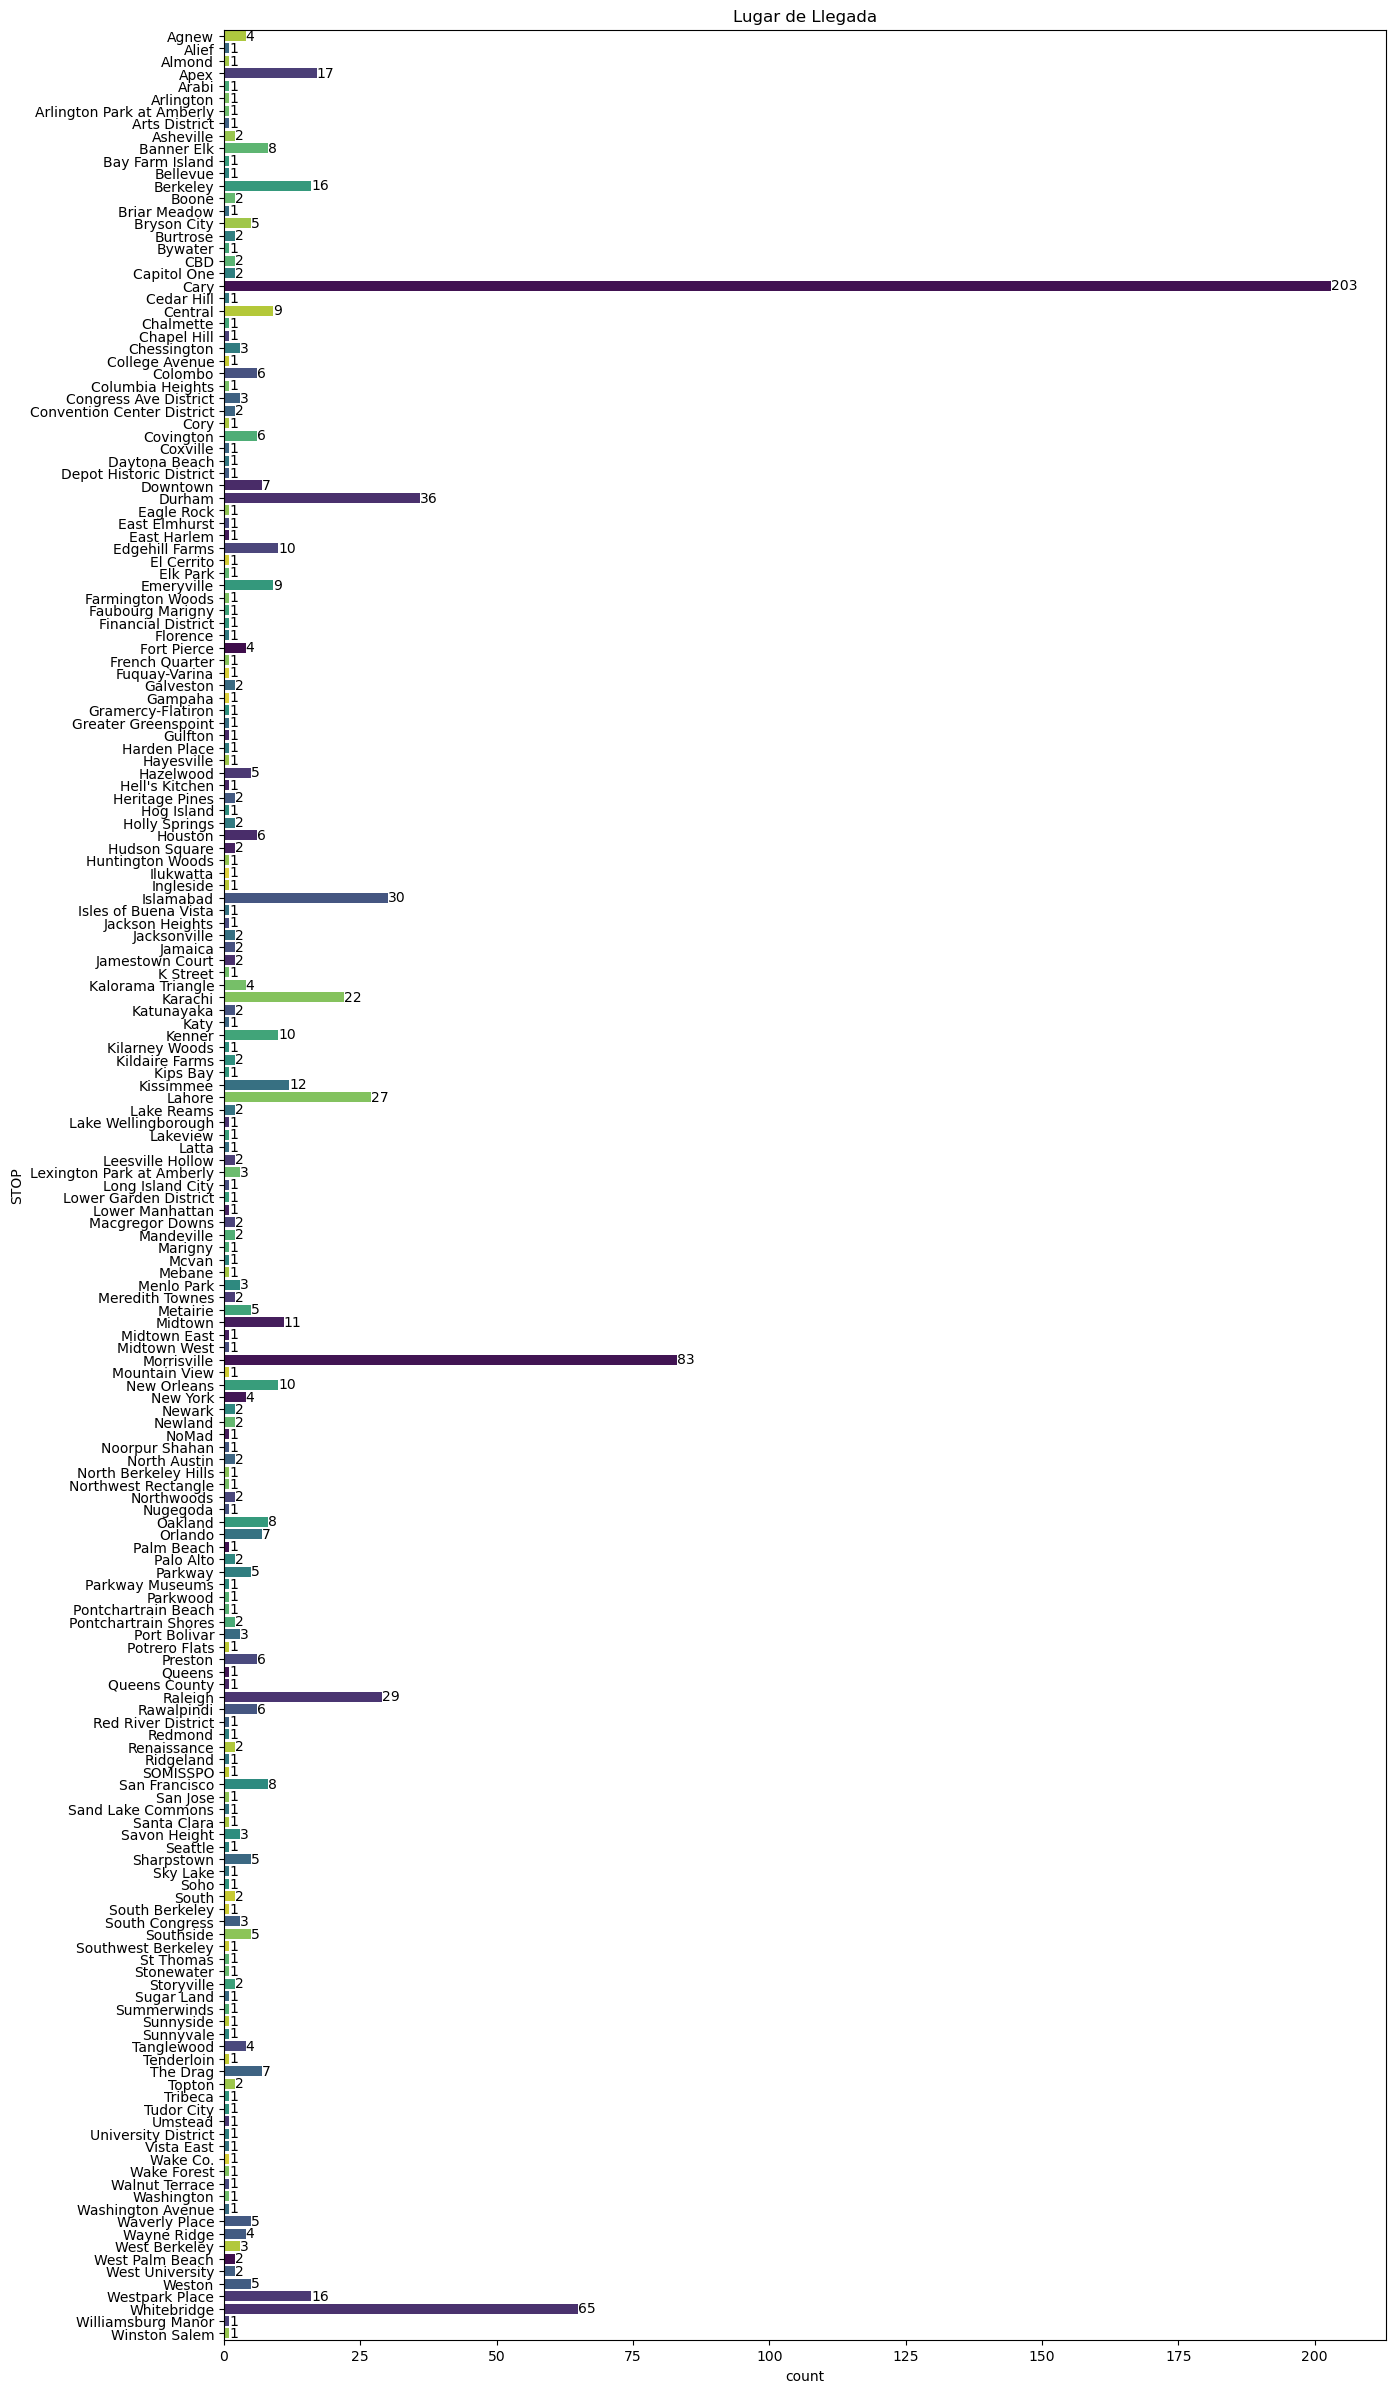

In [47]:
fig, ax = mat.subplots(figsize=(15,30))
# Ordenar alfabéticamente
orden = sorted(df['STOP'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='STOP',
    order=orden,
    hue='STOP',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)
# Título
ax.set_title('Lugar de Llegada')
# Agregar totales
for container in ax.containers:
    ax.bar_label(container)
mat.show()



<center>
<h3>Conclusión</h3>
</center>

En este trabajo quedó demostrado que, antes de intentar comprender cualquier conjunto de información, es fundamental revisarlo y ordenarlo detalladamente. Al trabajar con los registros de los viajes, vimos cómo la información del mundo real suele tener errores, estar incompleta o contener casos muy extremos que pueden darnos una idea equivocada de la realidad.

El mayor aprendizaje de este ejercicio fue entender la importancia de "limpiar" la información, separar lo que sirve de lo que no y corregir las fallas para quedarnos únicamente con datos confiables. Al final, esta organización y cuidado previo es lo que realmente nos permite ver el panorama completo, entender cómo se comportan los usuarios y tomar decisiones inteligentes en el mundo de los negocios digitales, basándonos en la realidad y no en suposiciones.